## Data Understanding

### About the Dataset
##### Dataset Description

The DiaBD dataset was introduced in 2025 to support diabetes research, risk assessment, predictive analytics, and healthcare planning in Bangladesh. The dataset contains 5,288 patient records and includes demographic information, clinical measurements, anthropometric indicators, and comorbidity-related variables.

##### Dataset Characteristics
|Property|Value|
|--------------|-----|
|Dataset Name|DiaBD|
|Country|Bangladesh|
|Number of Records|5,288|
|Target Variable|Diabetic|
|Publication Year|2025|


##### Dataset Citation
Prama, T. T., Rahman, M. J., Zaman, M., Sarker, F., & Mamun, K. A. (2025). _DiaBD: A diabetes dataset for enhanced risk analysis and research in Bangladesh_. Data in Brief, 61, 111746. DOI: 10.1016/j.dib.2025.111746.

### Loading Dataset

In [3]:
import pandas as pd

df = pd.read_csv("../data/diabd.csv")

df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [4]:
df.shape

(5288, 15)

The dataset has 5288 rows and 15 coloumns

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   str    
 2   pulse_rate              5288 non-null   int64  
 3   systolic_bp             5288 non-null   int64  
 4   diastolic_bp            5288 non-null   int64  
 5   glucose                 5288 non-null   float64
 6   height                  5288 non-null   float64
 7   weight                  5288 non-null   float64
 8   bmi                     5288 non-null   float64
 9   family_diabetes         5288 non-null   int64  
 10  hypertensive            5288 non-null   int64  
 11  family_hypertension     5288 non-null   int64  
 12  cardiovascular_disease  5288 non-null   int64  
 13  stroke                  5288 non-null   int64  
 14  diabetic                5288 non-null   str    
dty

In [6]:
df.describe()

,age,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke
count,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000,5288.000000
mean,45.745651,76.626135,133.996596,82.229576,7.563922,1.548886,53.644100,22.466581,0.031959,0.111006,0.033661,0.011346,0.003782
std,13.422024,12.229319,22.231752,12.479007,2.944381,0.080328,10.076059,8.819898,0.175908,0.314169,0.180372,0.105924,0.061389
min,21.000000,5.000000,62.000000,45.000000,0.000000,0.360000,3.000000,1.220000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,69.000000,119.000000,73.000000,6.000000,1.520000,46.775000,19.620000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,45.000000,76.000000,130.000000,81.000000,6.930000,1.550000,53.000000,21.870000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,55.000000,84.000000,147.000000,90.000000,8.130000,1.600000,59.900000,24.472500,0.000000,0.000000,0.000000,0.000000,0.000000
max,80.000000,133.000000,231.000000,119.000000,33.460000,1.960000,100.700000,574.130000,1.000000,1.000000,1.000000,1.000000,1.000000


### Checking for missing values

In [7]:
df.isnull().sum()

age                       0
gender                    0
pulse_rate                0
systolic_bp               0
diastolic_bp              0
glucose                   0
height                    0
weight                    0
bmi                       0
family_diabetes           0
hypertensive              0
family_hypertension       0
cardiovascular_disease    0
stroke                    0
diabetic                  0
dtype: int64

There are no missing values in the data.

### Checking for duplicates

In [14]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

In [15]:
df[df.duplicated()]

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic


There are no duplicated rows in the data.

### Inspecting target variable

In [9]:
df['diabetic'].value_counts()

diabetic
No     4946
Yes     342
Name: count, dtype: int64

<Axes: xlabel='diabetic', ylabel='count'>

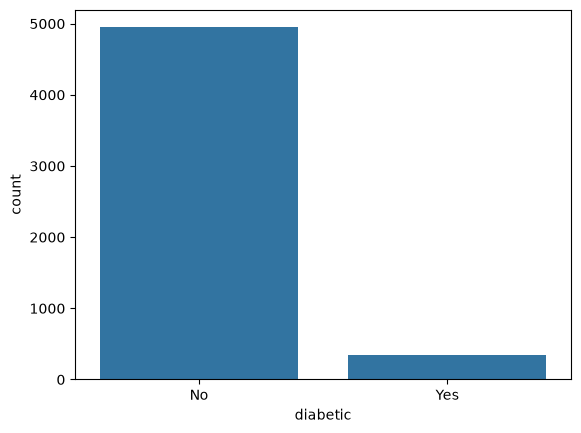

In [10]:
import seaborn as sns

sns.countplot(data=df, x='diabetic')

In [11]:
df['diabetic'].value_counts(normalize=True) * 100

diabetic
No     93.532526
Yes     6.467474
Name: proportion, dtype: float64

In the dataset of 5288 records, there are 4946 (93.53%) who are not diabetic and 342 (6.47%) who are diabetic.

In [12]:
df.groupby('gender')['diabetic'].value_counts()

gender  diabetic
Female  No          3524
        Yes          228
Male    No          1422
        Yes          114
Name: count, dtype: int64

In [13]:
df.groupby('gender')['diabetic'].value_counts(normalize='True') * 100

gender  diabetic
Female  No          93.923241
        Yes          6.076759
Male    No          92.578125
        Yes          7.421875
Name: proportion, dtype: float64

There are more males who are diabetic as compared to females based on proportion